# rfsoc4x2 — first run

Describe the setup, connect, and play one readout. Units are SI: Hz, seconds,
degrees, gain in -1 .. 1.


In [1]:
from pathlib import Path
from qcodes import Station
import numpy as np
import matplotlib.pyplot as plt

# all from the rfsoc4x2 package
from rfsoc4x2 import RFSoC, Config, ResonatorSpec, ConstantPulseSpec, RunConfig
from rfsoc4x2.sequences import readout

from qcodes.dataset import (load_by_run_spec, load_by_id)
from qcodes.interactive_widget import experiments_widget

In [2]:
IP_ADDRESS = "192.168.2.99"
path2db = Path("database/test.db")

## Setup

An element owns a DAC, a carrier frequency and (for a resonator) an ADC.
A pulse takes its DAC and carrier from its element, so it only says how far
it sits from that carrier.


In [3]:
resonator = ResonatorSpec(name='resonator', dac=1, adc=2, frequency=5e9, nqz=2, readout_length=1e-6, time_of_flight=0e-9)
readout_pulse = ConstantPulseSpec(name='readout', element='resonator', detuning=0, phase=0, gain=1, length=0.5e-6)

conf = Config(elements = [resonator], pulses = [readout_pulse])

## Connect

Building the RFSoC configures the channels and creates every pulse.
The board's pyro server must register as `myqick`; pass `ns_port` if it is not 8888.


In [5]:
station = Station()

rfsoc = RFSoC(name="rfsoc", ip=IP_ADDRESS, station=station, db_path=path2db, config=conf)

# tProc type and revision, sample rates, generator types, marker pins
print(rfsoc.qi.soccfg)


Using database at database\test.db.
Creating new QickInstrument with name rfsoc and IP 192.168.2.99.
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_4570ce6322434b93ac0e2fccd095ff31@192.168.2.99:45153
Adding QickInstrument rfsoc to the station.
QickInstrument rfsoc added to the station.
Applying configuration to QickInstrument rfsoc.
  element resonator (resonator) on DAC 1
  pulse readout (ConstantPulseSpec) on resonator
Configuration applied to QickInstrument rfsoc.
QICK running on RFSoC4x2, software version 0.2.418

Firmware configuration (built Tue Dec  9 20:12:40 2025):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 491.520
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B


## Run

`RunConfig` holds everything that belongs to the run rather than to the setup.
Start in `decimated` mode to see the waveform and read the real time of flight.


In [5]:
measurement_name = "test_measurement"
experiment_name = "test_experiment"
sample_name = "test_sample"

run_config = RunConfig(
    measurement_name=measurement_name,
    experiment_name=experiment_name,
    sample_name=sample_name,
    acquisition_mode="decimated",
    n_shots=20,
    soft_avgs=100,
)

In [6]:
run_id = rfsoc.run(readout(rfsoc.element("resonator")), config=run_config)

Running test_measurement (decimated).
Starting experimental run with id: 8. 


  0%|          | 0/100 [00:00<?, ?it/s]

Stored as run 8.


In [7]:
experiments_widget()

## Recover the data

`run()` returns the qcodes run id. In `accumulated` mode the result is a single
complex point; in `decimated` mode it is a trace, which is what you want here to
read the time of flight off.


In [8]:
dataset = load_by_id(run_id)
data = dataset.get_parameter_data()

name = list(data)[0]                    # 'iq', or 'iq_ch2' with several ADCs
block = data[name]
iq = np.asarray(block[name]).ravel()


print(dataset.name, '| run', dataset.run_id, '| captured:', list(block))
print('points:', iq.size)


test_measurement | run 8 | captured: ['iq', 'time']
points: 553


## Show it


pulse arrives at 300 ns


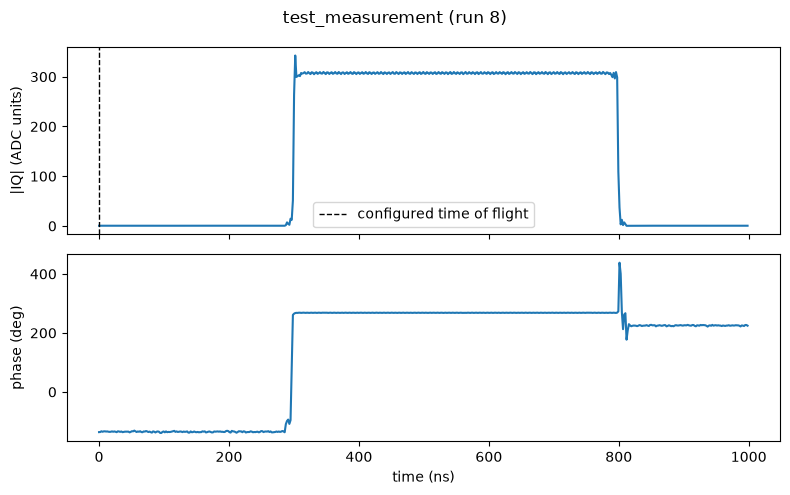

In [9]:
if 'time' in block:
    t = np.asarray(block['time']).ravel()

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
    ax1.plot(t * 1e9, np.abs(iq))
    ax1.set_ylabel('|IQ| (ADC units)')
    ax1.axvline(resonator.time_of_flight * 1e9, color='k', ls='--', lw=1,
                label='configured time of flight')
    ax1.legend()

    ax2.plot(t * 1e9, np.unwrap(np.angle(iq)) * 180 / np.pi)
    ax2.set_ylabel('phase (deg)')
    ax2.set_xlabel('time (ns)')
    fig.suptitle(f'{dataset.name} (run {dataset.run_id})')
    plt.tight_layout()

    # where the pulse actually arrives -> put this into time_of_flight
    above = np.abs(iq) > 0.5 * np.abs(iq).max()
    print(f'pulse arrives at {t[np.argmax(above)] * 1e9:.0f} ns')
else:
    # accumulated with no sweeps: one complex number
    point = iq[0]
    print(f'I = {point.real:.5f}   Q = {point.imag:.5f}')
    print(f'|IQ| = {np.abs(point):.5f}   phase = {np.angle(point, deg=True):.2f} deg')


[165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182
 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200
 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218
 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236
 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254
 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272
 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288 289 290
 291 292 293 294 295 296 297 298 299 300 301 302 303 304 305 306 307 308
 309 310 311 312 313 314 315 316 317 318 319 320 321 322 323 324 325 326
 327 328 329 330 331 332 333 334 335 336 337 338 339 340 341 342 343 344
 345 346 347 348 349 350 351 352 353 354 355 356 357 358 359 360 361 362
 363 364 365 366 367 368 369 370 371 372 373 374 375 376 377 378 379 380
 381 382 383 384 385 386 387 388 389 390 391 392 393 394 395 396 397 398
 399 400 401 402 403 404 405 406 407 408 409 410 41

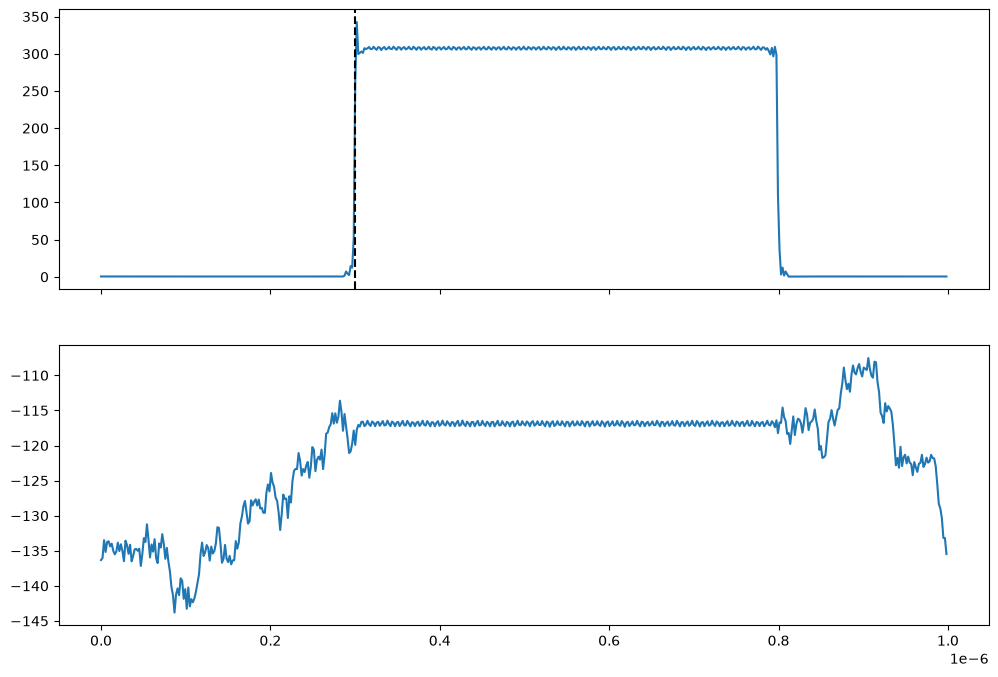

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)

time = block["time"].ravel()

iq_mod = np.abs(iq)
phase = np.unwrap(np.rad2deg(np.angle(iq)))

epsilon = 20
margin = 2e-9

index = np.where(iq_mod > epsilon)[0]

time_of_flight = time[index[0]] + margin


print(index)



ax[0].plot(time, iq_mod)
ax[0].axvline(time_of_flight, linestyle="--", color="black")
ax[1].plot(time, phase)

In [11]:
def detect_arrival(t, iq, pulse_length, smooth=7, min_snr=10):
    """Pulse arrival time (s) in a decimated trace, measured from the ADC trigger."""
    t = np.ravel(t)
    amp = np.convolve(np.abs(np.ravel(iq)), np.ones(smooth) / smooth, mode="same")
    # split the samples into "no signal" and "signal", threshold halfway between them
    thr = 0.5 * (amp.min() + amp.max())
    for _ in range(100):
        low, high = amp[amp <= thr].mean(), amp[amp > thr].mean()
        thr, old = 0.5 * (low + high), thr
        if abs(thr - old) < 1e-9 * high:
            break
    snr = (high - low) / amp[amp <= thr].std()
    above = amp > thr
    if snr < min_snr:
        raise RuntimeError(f"no clear pulse (S/N {snr:.1f}): average more")
    if above[:smooth].any():
        raise RuntimeError("pulse already there when the ADC starts: trigger at the pulse start")
    if above[-smooth:].any():
        raise RuntimeError("pulse still on when the window ends: use a longer window")
    i = np.argmax(above)                              # first sample above the threshold
    j = len(above) - 1 - np.argmax(above[::-1])       # last sample above the threshold
    arrival = np.interp(thr, amp[i - 1:i + 1], t[i - 1:i + 1])  # between the two samples
    width = t[j] - t[i]
    if abs(width - pulse_length) > 0.2 * pulse_length:
        raise RuntimeError(f"pulse looks {width*1e9:.0f} ns long, expected {pulse_length*1e9:.0f} ns")
    return arrival

In [12]:
arrival = detect_arrival(time, iq, readout_pulse.length)

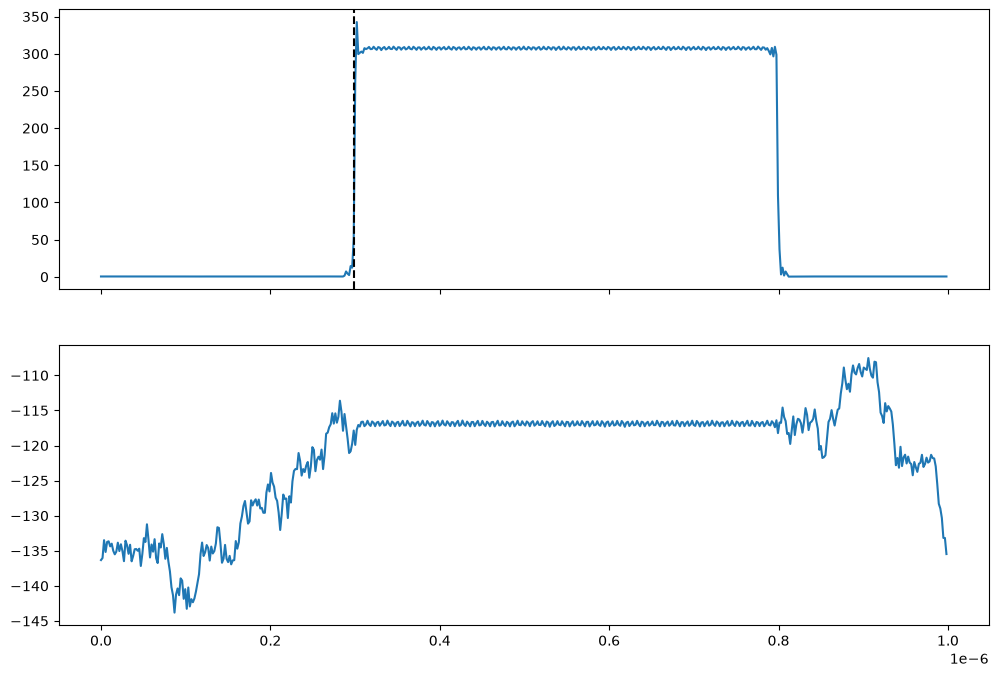

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)

time = block["time"].ravel()

iq_mod = np.abs(iq)
phase = np.unwrap(np.rad2deg(np.angle(iq)))


ax[0].plot(time, iq_mod)
ax[0].axvline(arrival, linestyle="--", color="black")
ax[1].plot(time, phase)

## Autocalibration

decimated buffer : 16384 samples
window           : 1000 ns -> 553 samples (1.81 ns each)
averaging        : 29 hardware x 10 software
estimated time   : 0.1 s
Running autocalibration for resonator at 5000000000.0 Hz.
Running autocalibrate_tof_resonator (decimated).
Starting experimental run with id: 13. 


  0%|          | 0/10 [00:00<?, ?it/s]

Stored as run 13.
arrival 298.87 ns + margin 5.00 ns = 303.87 ns (was 0.00 ns)
Updating resonator: time_of_flight from 0.0 to 3.038734696122944e-07
Applied updated spec for resonator to hardware.
Resonator resonator spec updated with time-of-flight delay: 303.87 ns


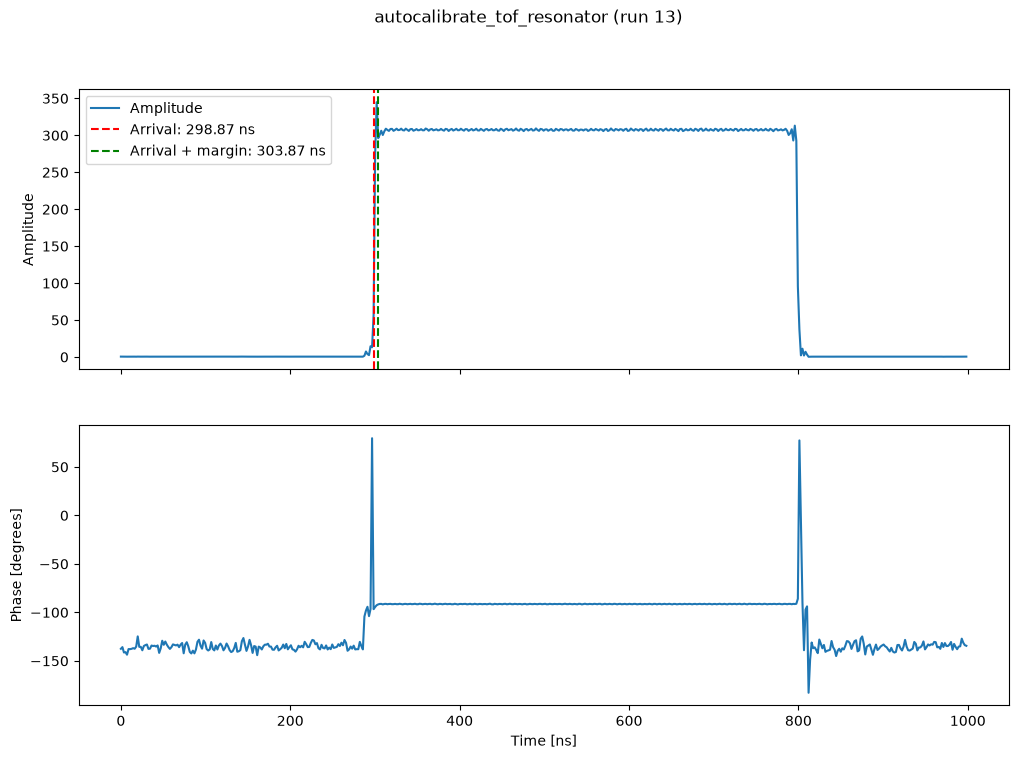

In [ ]:
from rfsoc4x2.programs.tof_calibration import tof_calibration

tof, run_id = tof_calibration(
    rfsoc=rfsoc,
    resonator=rfsoc.element("resonator"),
    pulse_length=readout_pulse.length,
    window=1e-6,
    margin=5e-9,
    smooth=7,
    min_snr=10,
    soft_avg=10,
    verbose=True,
    plot=True
)

In [ ]:
resonator.dac.channel_num

1